In the second part of this assignment, we will implement K-means Clustering and kernel K-means Clustering.

In [43]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn import metrics

**K-means Clustering Implementation**

Follow the comments! They'll give you instructions on what to code.

In [44]:
def kmeans(data, k):
    # First, randomly pick k data points for the centers of the initial clusters. Maybe you should use the np.random.choice() function.
    # Afterwards, initialize the clusters.
    num_data = np.shape(data)[0]
    # Choose k points among 0 ~ N -1
    cluster_means = data[np.random.choice(range(num_data), k)]
    # Used brodcasting using by np.expand_dims
    # data: (N, D) | cluster_means: (K, D) -> (K, N, D)
    # axis = 2 -> calculate L2 Norm of D (distance)
    mean_dist_mat = np.linalg.norm(np.expand_dims(data, axis = 0) - np.expand_dims(cluster_means, axis = 1), axis = 2)
    cluster_allocation = np.argmin(mean_dist_mat, axis = 0)

    # Update the clusters until convergence.
    updated = True
    while updated:
        updated = False

        # Calculate the cluster means
        for i in range(k):
          if np.sum(cluster_allocation == i) > 0:
            cluster_means[i] = np.sum(data[cluster_allocation == i],axis = 0) / np.sum(cluster_allocation == i)
          else:
            # Empty cluster occurred
            cluster_means[i] = data[np.random.choice(num_data)]

        # Find out which new cluster each data point belongs to
        mean_dist_mat = np.linalg.norm(np.expand_dims(data, axis = 0) - np.expand_dims(cluster_means, axis = 1), axis = 2)
        new_cluster_allocation = np.argmin(mean_dist_mat, axis = 0)

        # Update the cluster allocation. If nothing changes, exit the loop and return the converged result.
        if not np.array_equal(cluster_allocation, new_cluster_allocation):
          updated = True
          cluster_allocation = new_cluster_allocation
        else:
          loss = np.sum(np.min(mean_dist_mat, axis = 0))

    return cluster_allocation, loss

**Kernel K-means Clustering Implementation**

We will now implement Kernel K-means Clustering using Gaussian kernel.

* Gaussian Kernel:
$$K(x, x')=e^\frac{-||x-x'||^2}{2\sigma^2} $$

**Kernel Trick**
$$||\phi(x) - \mu_c||^2 = \phi(x)\cdot\phi(x) - 2\phi(x)\cdot\mu_c + \mu_c\cdot\mu_c$$

In [45]:
# This function should return the cluster labels and the value of the objective function for kernel k-means.
def kernel_kmeans(data, k, s, kernel):
    # The variable s refers to the value of sigma in the Gaussian kernel.
    # First, randomly pick k data points for the centers of the initial clusters. Maybe you should use the np.random.choice() function.
    # Afterwards, initialize the clusters.
    num_data = np.shape(data)[0]
    cluster_means = data[np.random.choice(range(num_data), k)]
    mean_dist_mat = np.linalg.norm(np.expand_dims(data, axis = 0) - np.expand_dims(cluster_means, axis = 1), axis = 2)
    cluster_allocation = np.argmin(mean_dist_mat, axis = 0)
    # Pre-calculate kernel values and save it in a matrix.
    # You can use sklearn.metrics.pairwise_distances(data) to get the pairwise distance of vectors in the data.
    # Gaussian kernel
    if kernel == 'gaussian':
        pre_cal = np.exp(- np.square(metrics.pairwise_distances(data)) / (2 * (s ** 2)))
    else:
        print("no such kernel")
        return None, None

    # Update the clusters until convergence.
    updated = True
    while updated:
        updated = False
        # Find out which new cluster each data point belongs to
        for idx in range(k):
          num_points = np.sum(cluster_allocation == idx)
          if num_points == 0:
            # Empty cluster occurred
            random_idx = np.random.choice(num_data)
            cluster_allocation[random_idx] = idx
            num_points = 1
          # Use Kernel Trick
          mean_dist_mat[idx] = 1 - 2 * np.sum(pre_cal[:, cluster_allocation == idx], axis = 1) / num_points + np.sum(pre_cal[cluster_allocation == idx][:, cluster_allocation == idx]) / (num_points**2)
        new_cluster_allocation = np.argmin(mean_dist_mat, axis = 0)

        # Update cluster allocation. If nothing changes, exit the loop and return the converged result.
        if not np.array_equal(cluster_allocation, new_cluster_allocation):
            updated = True
            cluster_allocation = new_cluster_allocation
        else:
            loss = np.sum(np.min(mean_dist_mat, axis = 0))

    return cluster_allocation, loss


Now, implementation is done.

Let's check the model's performance with an example we've seen in class.


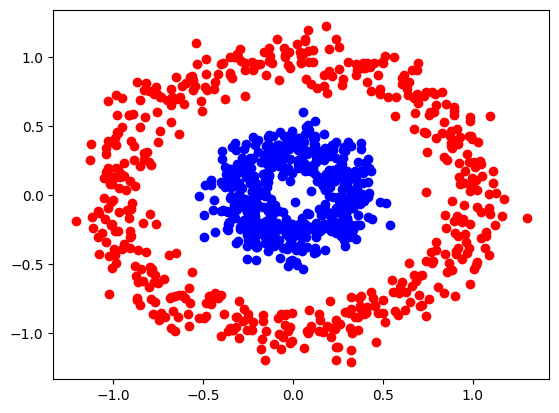

In [46]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=1000, noise = 0.1, factor = 0.3, random_state = 10)
plt.figure()
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue')
plt.show()

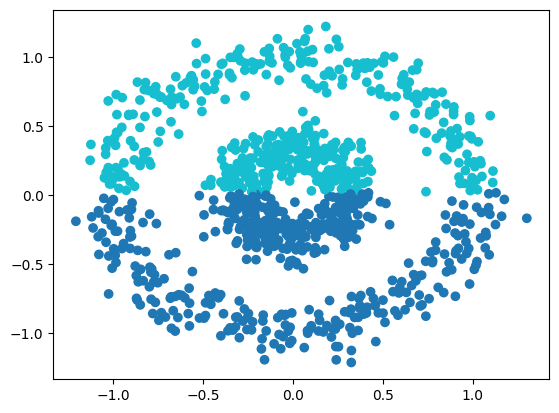

NMI score of K-means clustering:  0.0004158620733026639


In [47]:
# Run k-means clustering. This cell should print the NMI score of your model.
np.random.seed(42)
loss = np.inf
for _ in range(10):
  k = 2
  kmeans_result, loss_tmp = kmeans(X, k)
  if loss_tmp < loss:
    loss = loss_tmp
    best_kmeans_result = kmeans_result
    nmi_score = metrics.normalized_mutual_info_score(y, kmeans_result)

# Visualize the result of the k-means clustering.
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c = best_kmeans_result, cmap = 'tab10')
plt.show()
print("NMI score of K-means clustering: ", nmi_score)

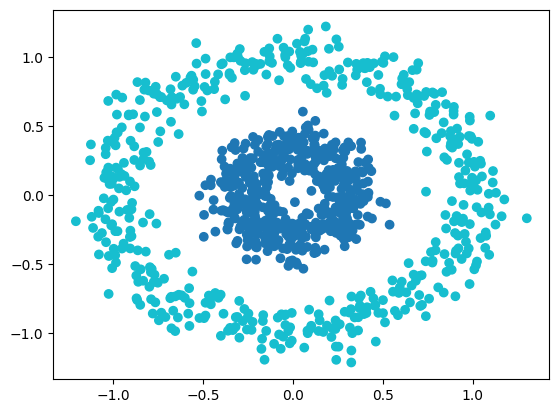

NMI score of kernel K-means clustering:  1.0


In [48]:
# Run kernel k-means clustering. This cell should print the NMI score of your model.
# Feel free to experiment with hyperparameter s (Use 0.5 as default)
np.random.seed(42)
loss = np.inf
for _ in range(10):
    k = 2
    kkmeans_result,loss_tmp = kernel_kmeans(X, k, s = 0.5, kernel = 'gaussian')
    if loss > loss_tmp:
        loss = loss_tmp
        best_kkmeans_result = kkmeans_result
        score = metrics.normalized_mutual_info_score(y, kkmeans_result)

# Visualize the result of the kernel k-means clustering.
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c = best_kkmeans_result, cmap = 'tab10')
plt.show()
print("NMI score of kernel K-means clustering: ",score)